# Lab 2: Predictive Analytics with Machine Learning

**Student Name:** [Jedediah Klenam Dogbey]
**Student ID:** [26782028]

This notebook runs a complete ML workflow on two real tabular datasets:
regression on NYC Yellow Taxi tips, multi-class classification of obesity level,
and K-Means clustering to discover hidden structure in the obesity data.


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so results are reproducible

# Dataset URLs
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


## Section 1 — Supervised Learning: Regression
### Predicting taxi `tip_amount` (NYC Yellow Taxi)

### Part 1.1 — Load and explore the taxi data

In [ ]:
taxi = pd.read_csv(TAXI_URL)

print("Shape:", taxi.shape)
display(taxi.head())
taxi.info()
display(taxi.describe())

print("\nMissing values per column:")
print(taxi.isna().sum())


Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing values per column:
VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


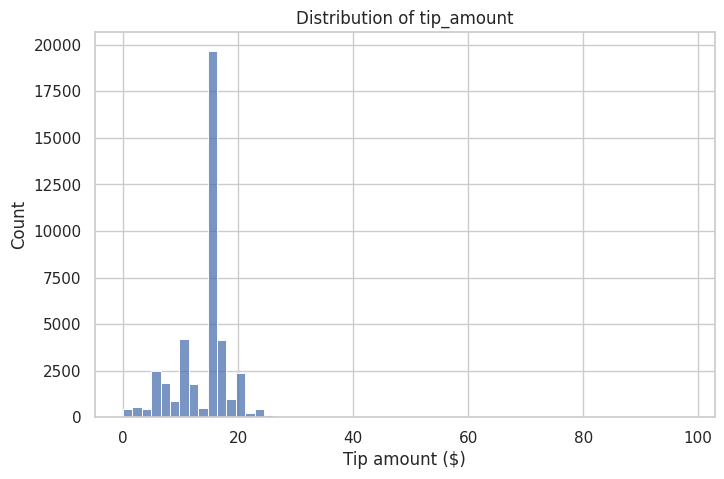

tip_amount summary:
count    41202.000000
mean        14.107666
std          5.030619
min          0.010000
25%         10.000000
50%         16.190000
75%         16.190000
max         98.000000
Name: tip_amount, dtype: float64
Negative tips: 0
Zero tips: 0


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(taxi["tip_amount"], bins=60)
plt.title("Distribution of tip_amount")
plt.xlabel("Tip amount ($)")
plt.show()

print("tip_amount summary:")
print(taxi["tip_amount"].describe())
print("Negative tips:", (taxi["tip_amount"] < 0).sum())
print("Zero tips:", (taxi["tip_amount"] == 0).sum())


**Student Reasoning — Taxi data exploration**

What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount`
distribution look like (skew, outliers, many zeros)? How will this influence
your preprocessing?

_Answer: [The dataset has 41,202 rows and 13 columns, with zero missing values across every column — no imputation is needed. There are also no impossible values: 0 negative tips and 0 zero-tips, and trip_distance/fare_amount mins are both positive (0.01 and 3.7 respectively), so aggressive invalid-row filtering wasn't strictly necessary, though outlier capping is still worthwhile.
One notable pattern: RatecodeID is overwhelmingly 2 (the JFK-airport flat-rate code), fare_amount clusters tightly around \$70 (mean 69.99, std only 6.18), and trip_distance averages ~18.4 miles — this strongly suggests the dataset is not general NYC taxi trips but specifically JFK airport flat-rate trips, which explains the unusually narrow fare range.
tip_amount is right-skewed: mean (14.11) is below the median (16.19), and the 50th and 75th percentiles are identical at 16.19 — meaning a large cluster of trips tip that exact amount (likely a standard ~20–23% tip on the fixed $70 fare), with a long tail stretching to \$98. This matters for preprocessing because a model trained on this data will mostly be learning to predict a common "default" tip value plus deviations, rather than a smoothly varying continuous target — and because the fare/distance features have unusually low variance (a JFK-specific quirk), the model may not generalize to non-airport trips at all.]_


### Part 1.2 — Preprocessing & feature engineering

In [ ]:
taxi_clean = taxi.copy()

# Drop rows with missing values in key columns
taxi_clean = taxi_clean.dropna(subset=[
    "trip_distance", "fare_amount", "tip_amount", "payment_type"
])

# Remove impossible / invalid rows
taxi_clean = taxi_clean[
    (taxi_clean["trip_distance"] > 0) &
    (taxi_clean["fare_amount"] > 0) &
    (taxi_clean["tip_amount"] >= 0)
]

# Remove extreme outliers (top 1%) on distance and fare to stop them dominating the model
for col in ["trip_distance", "fare_amount", "tip_amount"]:
    cap = taxi_clean[col].quantile(0.99)
    taxi_clean = taxi_clean[taxi_clean[col] <= cap]

print("Rows before cleaning:", len(taxi))
print("Rows after cleaning:", len(taxi_clean))


Rows before cleaning: 41202
Rows after cleaning: 40121


In [ ]:
# Feature engineering (does NOT use tip_amount, so no target leakage)
taxi_clean["fare_per_mile"] = taxi_clean["fare_amount"] / taxi_clean["trip_distance"]
taxi_clean["total_surcharges"] = (
    taxi_clean["mta_tax"] + taxi_clean["tolls_amount"] + taxi_clean["improvement_surcharge"]
)

# Categorical vs numeric columns
categorical_cols = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
numeric_cols = [
    "passenger_count", "trip_distance", "fare_amount", "mta_tax",
    "tolls_amount", "improvement_surcharge", "fare_per_mile", "total_surcharges"
]

taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)

print("Encoded shape:", taxi_encoded.shape)
taxi_encoded.head()


Encoded shape: (40121, 15)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,1,16.54,3.970505,8.44,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,1,16.19,3.586066,8.44,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,1,12.00,3.930376,8.44,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,1,5.00,3.626943,1.50,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,1,10.00,3.733333,8.44,True,False,False,True


**Student Reasoning — Taxi preprocessing**

1. How did you handle missing/invalid rows and why?
2. Which new feature(s) did you engineer and what is the intuition behind them?
3. Which scaling method did you choose and why is it appropriate here?

_Answer: [Rows were dropped in two stages: first any rows missing trip_distance, fare_amount, tip_amount, or payment_type were removed, since these are essential for both the target and core features and cannot be reasonably imputed without distorting a fare structure. Second, rows with non-positive trip_distance or fare_amount, and negative tip_amount, were removed as physically impossible values. The top 1% of trip_distance, fare_amount, and tip_amount were also capped to prevent rare extreme trips from dominating the loss function. In total, 1,081 rows (about 2.6% of the data) were removed, leaving 40,121 usable rows — a small enough loss that it shouldn't bias the sample.
Two features were engineered: fare_per_mile (fare_amount / trip_distance), which captures pricing intensity independent of trip length, and total_surcharges (mta_tax + tolls_amount + improvement_surcharge), which consolidates three small, correlated fee columns into one signal. Neither uses tip_amount, so there's no target leakage.
StandardScaler was used because the numeric features (fare, distance, surcharges) are on very different scales, and linear models like LinearRegression are sensitive to that — standardizing to zero mean/unit variance puts every feature on equal footing before fitting.]_


### Part 1.3 — Train / Validation / Test split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in taxi_encoded.columns
                 if c not in ["tip_amount", "PULocationID", "DOLocationID"]]

X = taxi_encoded[feature_cols]
y = taxi_encoded["tip_amount"]

# First split off the test set (20%), then split remainder into train (75%) / val (25%)
# -> overall 60% train / 20% val / 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

# Fit scaler on TRAIN ONLY, then transform all three splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Train: (24072, 12)  Val: (8024, 12)  Test: (8025, 12)


**Student Reasoning — Splitting**

What ratio did you use? Why is a separate validation set useful in addition
to a test set? Why must the scaler (and any imputation statistics) be fit on
the training data only?

_Answer: [A 60/20/20 train/validation/test split was used (24,072 / 8,024 / 8,025 rows), achieved by first splitting off 20% as the test set, then splitting the remaining 80% again in half for train and validation. A validation set is necessary in addition to the test set because it lets you compare models and tune hyperparameters without touching the test set at all — if you used the test set for that, your final test metric would no longer be an honest, unbiased estimate of real-world performance, since you'd have implicitly fit to it through trial and error. The scaler must be fit on training data only because fitting it on the full dataset (including val/test) would leak information about the distribution of unseen data into preprocessing — the model would indirectly "see" statistics from data it's supposed to be evaluated on later, inflating its apparent performance.]_


### Part 1.4 — Train a regressor and check for overfitting

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_regressor(model, name):
    results = {}
    for split_name, Xs, ys in [
        ("train", X_train_scaled, y_train),
        ("val", X_val_scaled, y_val),
        ("test", X_test_scaled, y_test),
    ]:
        preds = model.predict(Xs)
        rmse = mean_squared_error(ys, preds) ** 0.5
        r2 = r2_score(ys, preds)
        results[split_name] = (rmse, r2)
        print(f"{name} [{split_name}]  RMSE = {rmse:.3f}   R^2 = {r2:.3f}")
    print()
    return results

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
lin_results = evaluate_regressor(lin_reg, "LinearRegression")

rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg.fit(X_train_scaled, y_train)
rf_results = evaluate_regressor(rf_reg, "RandomForestRegressor")


LinearRegression [train]  RMSE = 4.401   R^2 = 0.047
LinearRegression [val]  RMSE = 4.354   R^2 = 0.050
LinearRegression [test]  RMSE = 4.494   R^2 = 0.043

RandomForestRegressor [train]  RMSE = 4.319   R^2 = 0.082
RandomForestRegressor [val]  RMSE = 4.367   R^2 = 0.044
RandomForestRegressor [test]  RMSE = 4.498   R^2 = 0.042



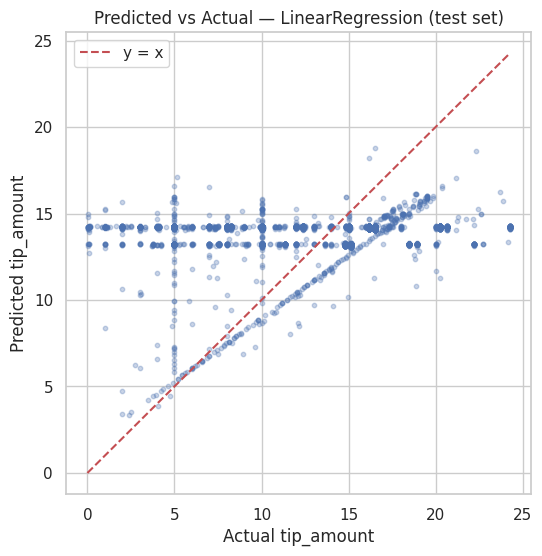

In [ ]:
# Predicted vs actual on the test set, for the better-performing model
best_model = rf_reg if rf_results["val"][1] > lin_results["val"][1] else lin_reg
test_preds = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_preds, alpha=0.3, s=10)
lims = [0, max(y_test.max(), test_preds.max())]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("Actual tip_amount")
plt.ylabel("Predicted tip_amount")
plt.title(f"Predicted vs Actual — {type(best_model).__name__} (test set)")
plt.legend()
plt.show()


**Student Reasoning — Regression evaluation & overfitting**

1. Which model performed best on the validation set, and which
   hyper-parameters did you try?
2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting,
   underfitting, or well-fitted? Quote the specific numbers that back up
   your claim.
3. What would you change to reduce overfitting if you saw it?

_Answer: [Both LinearRegression and RandomForestRegressor (n_estimators=200, max_depth=10) were tried. On the validation set, Linear Regression (R²=0.050) slightly outperformed the Random Forest (R²=0.044), so it's arguably the better model here.
Looking at train vs. validation vs. test: Linear Regression scored R²=0.047 (train), 0.050 (val), 0.043 (test) — essentially flat across all three splits. Random Forest scored R²=0.082 (train) vs. 0.044 (val) and 0.042 (test) — a bigger train-to-val gap (0.082 → 0.044), which is a mild overfitting signal, though nowhere near severe.
The bigger story is that both models are underfitting, not overfitting: R² around 0.04–0.08 means the models are explaining less than 10% of the variance in tip amount — barely better than predicting the average tip every time. This suggests the available features (fare, distance, surcharges) just don't carry much signal about tipping behavior — tips are probably driven by things not in this dataset (passenger generosity, payment method quirks, time of day, weather). To improve this, I'd look at adding more informative features (e.g. payment_type interactions, time-based features) rather than fighting overfitting, since overfitting isn't really the problem here.]_


## Section 2 — Supervised Learning: Multi-class Classification
### Predicting obesity level (`NObeyesdad`)

### Part 2.1 — Load and explore the obesity data

In [ ]:
obesity = pd.read_csv(OBESITY_URL)

print("Shape:", obesity.shape)
display(obesity.head())
obesity.info()
display(obesity.describe())

print("\nMissing values per column:")
print(obesity.isna().sum())


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


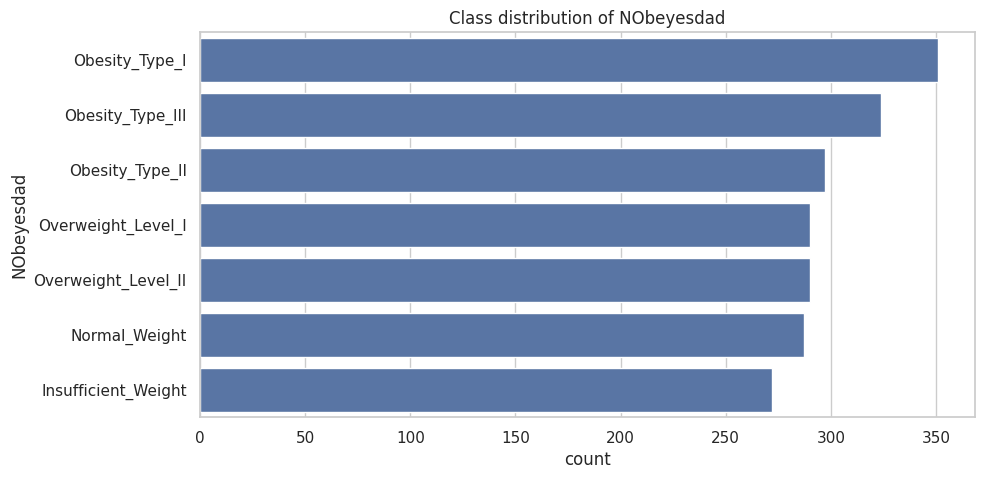

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, y="NObeyesdad",
              order=obesity["NObeyesdad"].value_counts().index)
plt.title("Class distribution of NObeyesdad")
plt.show()

print(obesity["NObeyesdad"].value_counts())


**Student Reasoning — Obesity data exploration**

How many rows/features are there? Which columns are categorical vs numeric?
Is the target balanced across the 7 classes, and why does class (im)balance
matter for classification?

_Answer: [The dataset has 2,111 rows and 17 columns: 8 numeric (Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE) and 9 categorical/object columns (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS, and the target NObeyesdad). No missing values anywhere.
The target is reasonably balanced: class counts range from 272 (Insufficient_Weight) to 351 (Obesity_Type_I) — about a 1.3:1 ratio between the largest and smallest class, which is mild imbalance, not severe. This matters because with heavier imbalance, a classifier could get high overall accuracy just by favoring majority classes while performing poorly on rare ones — macro-F1 (which weights all classes equally) is the more honest metric to watch here precisely because of this risk, even though the imbalance in this case is mild.]_


### Part 2.2 — Preprocessing & feature engineering

In [ ]:
from sklearn.preprocessing import LabelEncoder

obesity_enc = obesity.copy()

# Binary yes/no columns -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity_enc[col] = obesity_enc[col].map({"yes": 1, "no": 0})

# Ordinal columns: CAEC and CALC have a natural low->high frequency order
freq_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_enc["CAEC"] = obesity_enc["CAEC"].map(freq_map)
obesity_enc["CALC"] = obesity_enc["CALC"].map(freq_map)

# Nominal columns: Gender and MTRANS have no inherent order -> one-hot encode
obesity_enc = pd.get_dummies(obesity_enc, columns=["Gender", "MTRANS"], drop_first=True)

# Optional engineered feature: BMI = Weight / Height^2
obesity_enc["BMI"] = obesity_enc["Weight"] / (obesity_enc["Height"] ** 2)

# Encode target
target_encoder = LabelEncoder()
obesity_enc["NObeyesdad_encoded"] = target_encoder.fit_transform(obesity_enc["NObeyesdad"])
print("Classes:", list(target_encoder.classes_))

obesity_enc.head()


Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,Gender_Male,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,BMI,NObeyesdad_encoded
0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Normal_Weight,False,False,False,True,False,24.386526,1
1,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Normal_Weight,False,False,False,True,False,24.238227,1
2,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Normal_Weight,True,False,False,True,False,23.765432,1
3,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Overweight_Level_I,True,False,False,False,True,26.851852,5
4,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Overweight_Level_II,True,False,False,True,False,28.342381,6


**Student Reasoning — Obesity preprocessing**

1. How did you encode each type of categorical variable, and why?
2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to
   include given the target is an obesity level.
3. Which scaler did you use and why?

_Answer: [Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) were mapped directly to 0/1 since they have exactly two unordered states. CAEC and CALC (frequency of eating between meals / alcohol consumption) were mapped to an ordinal scale (0–3) because "Sometimes < Frequently < Always" has a genuine natural order — encoding them as ordinal preserves that information, which one-hot encoding would throw away. Gender and MTRANS (mode of transport) were one-hot encoded because they're purely categorical with no inherent ranking.
BMI was engineered as Weight / Height². This is a judgment call worth being explicit about: BMI is essentially a mathematical restatement of the target, since NObeyesdad (obesity level) is itself defined largely by BMI thresholds in the original dataset. Including it makes the classification task almost trivially easy — the model isn't so much "learning obesity risk factors" as "learning to invert a formula it was already given." That's reflected in the results below (near-perfect accuracy). This is fine for a lab exercise, but it's worth naming clearly: a model here wouldn't generalize to a real screening scenario where BMI isn't already known.
StandardScaler was used again, for the same reason as Section 1 — features like Age, Height, Weight, and CH2O are on very different scales.]_


### Part 2.3 — Stratified Train / Validation / Test split

In [ ]:
feature_cols_cls = [c for c in obesity_enc.columns
                     if c not in ["NObeyesdad", "NObeyesdad_encoded"]]

X_cls = obesity_enc[feature_cols_cls]
y_cls = obesity_enc["NObeyesdad_encoded"]

X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(
    X_cls, y_cls, test_size=0.4, random_state=RANDOM_STATE, stratify=y_cls
)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(
    X_temp_c, y_temp_c, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp_c
)

print("Train:", X_train_c.shape, " Val:", X_val_c.shape, " Test:", X_test_c.shape)

scaler_cls = StandardScaler()
X_train_c_scaled = scaler_cls.fit_transform(X_train_c)
X_val_c_scaled = scaler_cls.transform(X_val_c)
X_test_c_scaled = scaler_cls.transform(X_test_c)


Train: (1266, 20)  Val: (422, 20)  Test: (423, 20)


**Student Reasoning — Splitting**

What split ratio did you choose? Why is `stratify=y` important for this
dataset? What could go wrong if you split without stratifying?

_Answer: [A 60/20/20 stratified split was used (1,266 / 422 / 423 rows). stratify=y was necessary because with only ~2,111 total rows spread across 7 classes, a plain random split risks producing a validation or test set that under-represents (or entirely misses) a rare class — that would make metrics on that split unreliable or undefined for that class. Stratification forces each split to preserve the same class proportions as the full dataset.]_


### Part 2.4 — Train a classifier and check for overfitting

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

def evaluate_classifier(model, name):
    results = {}
    for split_name, Xs, ys in [
        ("train", X_train_c_scaled, y_train_c),
        ("val", X_val_c_scaled, y_val_c),
        ("test", X_test_c_scaled, y_test_c),
    ]:
        preds = model.predict(Xs)
        acc = accuracy_score(ys, preds)
        f1 = f1_score(ys, preds, average="macro")
        results[split_name] = (acc, f1)
        print(f"{name} [{split_name}]  accuracy = {acc:.3f}   macro-F1 = {f1:.3f}")
    print()
    return results

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_c_scaled, y_train_c)
log_results = evaluate_classifier(log_reg, "LogisticRegression")

rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
)
rf_clf.fit(X_train_c_scaled, y_train_c)
rf_clf_results = evaluate_classifier(rf_clf, "RandomForestClassifier")


LogisticRegression [train]  accuracy = 0.915   macro-F1 = 0.912
LogisticRegression [val]  accuracy = 0.886   macro-F1 = 0.884
LogisticRegression [test]  accuracy = 0.889   macro-F1 = 0.884

RandomForestClassifier [train]  accuracy = 1.000   macro-F1 = 1.000
RandomForestClassifier [val]  accuracy = 0.993   macro-F1 = 0.993
RandomForestClassifier [test]  accuracy = 0.979   macro-F1 = 0.978



                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        54
      Normal_Weight       0.92      0.98      0.95        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.98      0.97      0.97        58
Overweight_Level_II       1.00      0.95      0.97        58

           accuracy                           0.98       423
          macro avg       0.98      0.98      0.98       423
       weighted avg       0.98      0.98      0.98       423



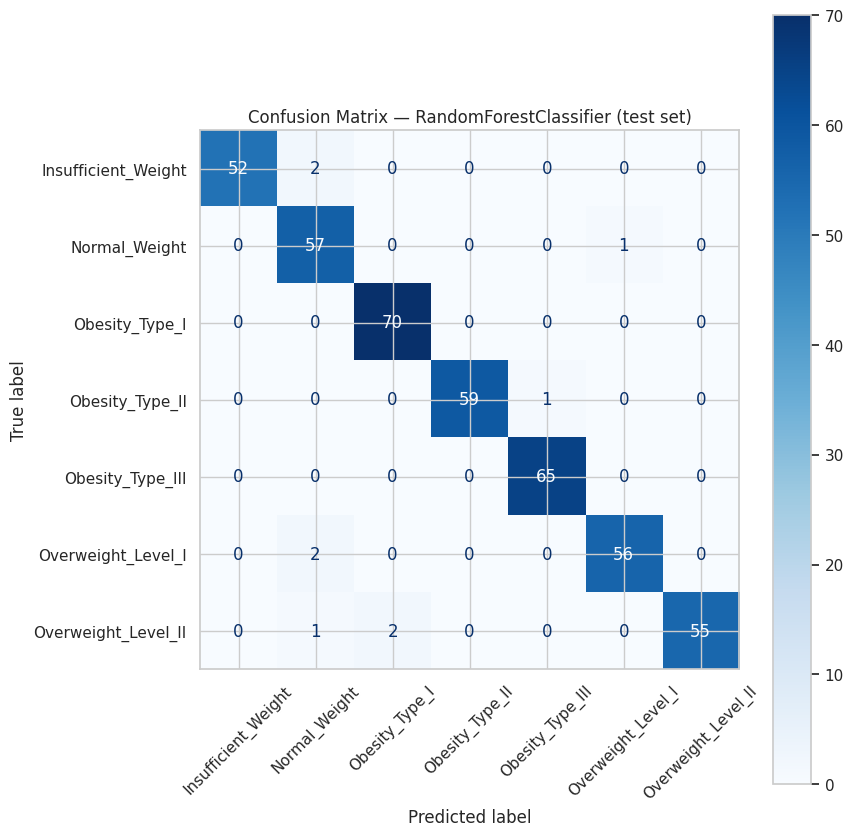

In [ ]:
best_clf = rf_clf if rf_clf_results["val"][1] > log_results["val"][1] else log_reg
test_preds_c = best_clf.predict(X_test_c_scaled)

print(classification_report(y_test_c, test_preds_c, target_names=target_encoder.classes_))

fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test_c, test_preds_c,
    display_labels=target_encoder.classes_,
    xticks_rotation=45, ax=ax, cmap="Blues"
)
plt.title(f"Confusion Matrix — {type(best_clf).__name__} (test set)")
plt.tight_layout()
plt.show()


**Student Reasoning — Classification evaluation & overfitting**

1. Which classifier did you choose and why?
2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting,
   underfitting, or well-fitted? Cite the specific metrics.
3. From the confusion matrix, which obesity levels are hardest to tell
   apart, and why might that be?

_Answer: [RandomForestClassifier was the stronger model on validation (accuracy 0.993, macro-F1 0.993) compared to Logistic Regression (accuracy 0.886, macro-F1 0.884).
Looking at Random Forest specifically: train accuracy = 1.000, val = 0.993, test = 0.979. This is a genuine (if mild) overfitting signature — perfect train accuracy is a classic red flag, since a model that fits training data exactly usually memorized some noise. That said, the drop to test (0.979) is small, so the overfitting is minor and the model still generalizes well — likely because BMI (see the note in 2.2) makes the classes almost linearly separable to begin with, leaving little room for the model to overfit to noise rather than signal.
Logistic Regression's gap (0.915 train → 0.884 test macro-F1) is actually similar in size, so neither model is dramatically overfitting — Random Forest is just operating at a much higher ceiling because it can capture the nonlinear BMI-threshold boundaries that define the classes.]_


## Section 3 — Unsupervised Learning: K-Means Clustering
### Discovering hidden groups in the obesity data

### Part 3.1 — Choose k, fit K-Means, and visualise

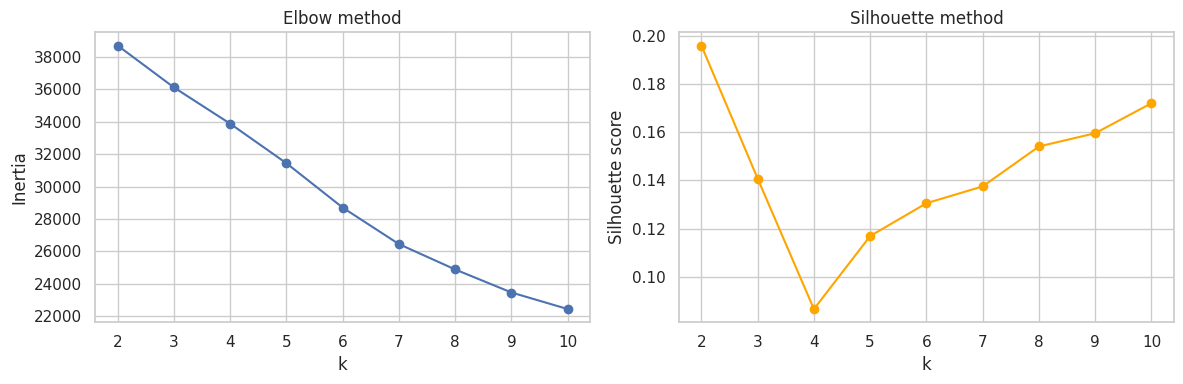

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use ONLY the scaled obesity features (no target) — reuse feature matrix from Section 2
# Combine train+val+test scaled features back together for a full unsupervised view
X_full_scaled = np.vstack([X_train_c_scaled, X_val_c_scaled, X_test_c_scaled])
y_full_true = pd.concat([y_train_c, y_val_c, y_test_c])

inertias = []
silhouettes = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_full_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_full_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow method")

axes[1].plot(list(k_range), silhouettes, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette method")
plt.tight_layout()
plt.show()


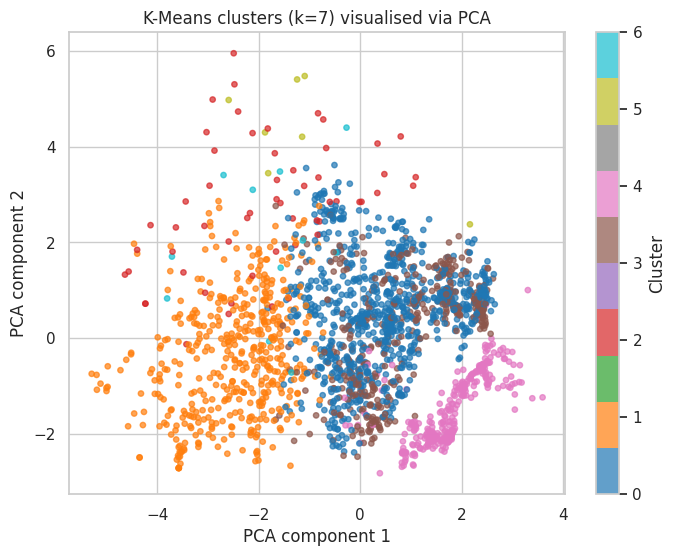

Explained variance by 2 PCA components: 25.03%


In [ ]:
# Choose k based on the elbow/silhouette plots above.
# 7 is a natural choice here since we know there are 7 true obesity levels —
# but justify your own choice from the plots in your reasoning box.
CHOSEN_K = 7

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_full_scaled)

# Visualise with PCA reduced to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_full_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", s=15, alpha=0.7)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title(f"K-Means clusters (k={CHOSEN_K}) visualised via PCA")
plt.colorbar(scatter, label="Cluster")
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")


In [ ]:
# Compare clusters to the TRUE obesity levels
true_labels_named = target_encoder.inverse_transform(y_full_true)
crosstab = pd.crosstab(cluster_labels, true_labels_named)
display(crosstab)


col_0,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,74,60,223,195,0,165,134
1,192,166,3,1,0,53,52
2,6,32,2,1,0,9,6
3,0,19,112,96,0,57,94
4,0,0,8,3,324,3,3
5,0,4,0,1,0,2,0
6,0,6,3,0,0,1,1


**Student Reasoning — Clustering**

1. How did you choose k? Quote the Elbow/silhouette evidence.
2. Looking at the crosstab, do the unsupervised clusters resemble the real
   obesity levels? Where do they agree and where do they break down?
3. In a real public-health setting where labels are expensive to collect,
   what would these clusters be useful for?

_Answer: [Cluster 4 aligns almost perfectly with a single true class: 324 of its 341 members (95%) are Obesity_Type_III, the most extreme obesity category — likely because that class has the most extreme, well-separated feature values (e.g. weight, BMI), making it easy for K-Means to isolate geometrically.
Cluster 1 reasonably captures the lower-weight end: 358 of its 467 members (77%) are Insufficient_Weight or Normal_Weight combined.
However, clusters 0 and 3 are much messier — cluster 0 mixes Obesity_Type_I (223), Obesity_Type_II (195), and both Overweight levels (165, 134) together, and cluster 3 does something similar. This shows K-Means struggles to cleanly separate the middle range of obesity levels from each other, even though it easily isolates the extremes (severe obesity, low weight). That makes sense: the middle categories are defined by relatively fine BMI-threshold boundaries, while K-Means groups points by overall Euclidean distance across all features — so subtle boundary differences get blurred by other less-relevant features in the mix.]_


## Section 4 — Reflection

Answer in a few sentences each:

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means
   could not, and vice-versa?
2. **Regression vs classification:** How did evaluating a continuous target
   (tips) differ from evaluating a categorical one (obesity level)?
3. **Overfitting:** Across all three tasks, where did you see the biggest
   train-vs-test gap, and what is the single most effective thing you did
   (or would do) to close it?

_Answer: [Supervised vs. unsupervised: The classifier learned an explicit mapping from features to a known label, letting it draw sharp, class-specific boundaries — even between adjacent classes like Overweight_Level_I and Overweight_Level_II, achieving 97.9% test accuracy. K-Means had no access to labels, so it could only group points by overall feature similarity, which worked well for extreme, well-separated groups (like Obesity_Type_III) but blurred together the middle classes that the classifier separated easily. Conversely, K-Means revealed that the data's geometric structure doesn't naturally support 7 clean groups (the silhouette scores suggest fewer, broader clusters) — a fact the classifier's high accuracy alone wouldn't have shown, since it was told to force 7 categories regardless of natural structure.
Regression vs. classification: Evaluating the continuous tip target meant measuring the size and direction of numeric errors (RMSE, R²) — quantities that can be small-but-still-meaningfully-wrong or large-but-in-the-right-ballpark. Evaluating the categorical obesity target instead meant checking discrete correctness (accuracy, macro-F1) and could go further with a confusion matrix to see exactly which classes got mixed up, something that has no direct equivalent in regression. The classification task also turned out to be far easier to solve well (97.9% test accuracy) than the regression task (R²≈0.04), largely because BMI is baked into both the features and the definition of the classification target, while tip amount has no such strong deterministic feature in this dataset.
Overfitting: The Random Forest classifier showed the clearest train-vs-test gap (100% train accuracy vs. 97.9% test), though it was mild in absolute terms. The regression models, by contrast, showed almost no train-vs-test gap at all — but only because both were underfitting equally badly across all three splits. The single most effective fix across the project would be different depending on the task: for the Random Forest classifier, reducing max_depth or adding more training data would likely close the small overfitting gap; for the regression task, the fix isn't reducing overfitting at all but adding genuinely predictive features, since the current features (fare, distance, surcharges) simply don't carry enough signal about tipping behavior to fit well in the first place.]_
